In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd drive/MyDrive/UNISINOS/IA\ Aplicada\ à\ Saúde

/content/drive/MyDrive/UNISINOS/IA Aplicada à Saúde


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# configurações

batch_size = 64
num_epochs = 5
learning_rate = 0.001

# verificar se existe GPU, se existir, roda o treinamento em GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Dispositivo em uso: {device}')

Dispositivo em uso: cpu


In [9]:
!ls ../chest_xray/chest_xray/train/

NORMAL	PNEUMONIA


In [11]:
transform = transforms.Compose([
                    transforms.Resize((128, 128)),
                    transforms.Grayscale(num_output_channels=1),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.5], std=[0.5])
                  ])

In [12]:
train_data = datasets.ImageFolder('../chest_xray/chest_xray/train/', transform=transform)
val_data = datasets.ImageFolder('../chest_xray/chest_xray/val/', transform=transform)
test_data = datasets.ImageFolder('../chest_xray/chest_xray/test/', transform=transform)

In [13]:
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

class_names = train_data.classes

In [14]:
print(class_names)

['NORMAL', 'PNEUMONIA']


In [15]:
class SimpleMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 128, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 2)
    )

  def forward(self, x):
    return self.model(x)

In [16]:
mlp = SimpleMLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp.parameters(), lr=learning_rate)

In [18]:
for epoch in range(num_epochs):
  mlp.train()

  train_correct = 0

  print(f'Época {epoch+1} / {num_epochs}')

  for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = mlp(images)

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    batch_correct = (outputs.argmax(dim=1) == labels).sum().item()
    train_correct += batch_correct

    if batch_idx % 10 == 0:
      print(f'Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item()}')
      print(f'Acurácia: {train_correct / ((batch_idx + 1) * batch_size)}')

  mlp.eval()

  val_correct = 0

  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
      outputs = mlp(images).argmax(1)

      val_correct = (outputs == labels).sum().item()

  print(f'Resumo da época{epoch+1}')
  print(f'Acurácia de validação: {val_correct / len(val_data)}')


Época 1 / 5
Batch 0/82 - Loss: 0.6884161829948425
Acurácia: 0.84375
Batch 10/82 - Loss: 0.29776614904403687
Acurácia: 0.8721590909090909
Batch 20/82 - Loss: 0.18349899351596832
Acurácia: 0.9069940476190477
Batch 30/82 - Loss: 0.14950017631053925
Acurácia: 0.9138104838709677
Batch 40/82 - Loss: 0.1031760573387146
Acurácia: 0.921875
Batch 50/82 - Loss: 0.169609934091568
Acurácia: 0.9237132352941176
Batch 60/82 - Loss: 0.19945913553237915
Acurácia: 0.9246926229508197
Batch 70/82 - Loss: 0.36233994364738464
Acurácia: 0.922975352112676
Batch 80/82 - Loss: 0.14065787196159363
Acurácia: 0.925733024691358
Resumo da época1
Acurácia de validação: 0.6875
Época 2 / 5
Batch 0/82 - Loss: 0.06445363163948059
Acurácia: 0.984375
Batch 10/82 - Loss: 0.15461784601211548
Acurácia: 0.953125
Batch 20/82 - Loss: 0.10123683512210846
Acurácia: 0.9471726190476191
Batch 30/82 - Loss: 0.07106375694274902
Acurácia: 0.9485887096774194
Batch 40/82 - Loss: 0.09404586255550385
Acurácia: 0.9489329268292683
Batch 50/82 

In [22]:
def evaluate_model(model, name):
  model.eval()

  all_preds = []
  all_labels = []

  correct = 0

  print(f'Avaliando o modelo {name}')

  for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
      outputs = model(images)
      preds = outputs.argmax(1)

      correct += (preds == labels).sum().item()

      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  print(f'Acurácia do modelo {name}: {correct / len(test_data)}')

  print(classification_report(all_labels, all_preds, target_names=class_names))

  cm = confusion_matrix(all_labels, all_preds)

  plt.figure(figsize=(6,6))

  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.xlabel('Predito')
  plt.ylabel('Real')
  plt.title('Matriz de Confusão')
  plt.show()


Avaliando o modelo MLP-01012025
Acurácia do modelo MLP-01012025: 0.7708333333333334
              precision    recall  f1-score   support

      NORMAL       0.94      0.41      0.58       234
   PNEUMONIA       0.74      0.98      0.84       390

    accuracy                           0.77       624
   macro avg       0.84      0.70      0.71       624
weighted avg       0.81      0.77      0.74       624



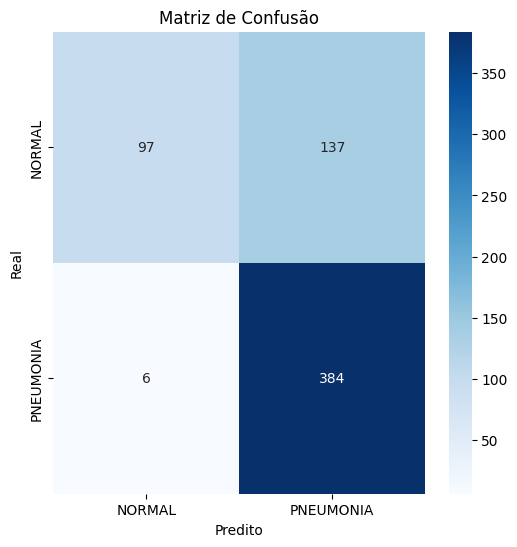

In [23]:
evaluate_model(mlp, 'MLP-01012025')